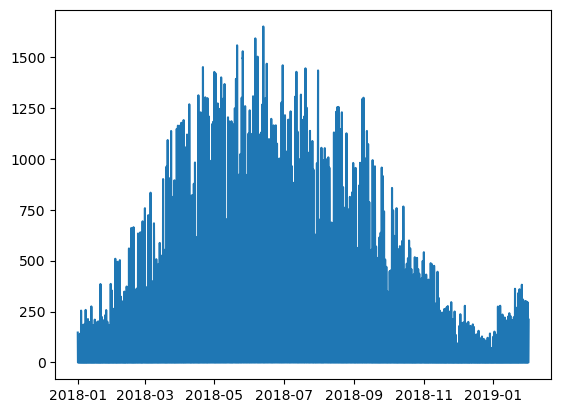

/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_4237/2106700032.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  light_data_2018['time'] = light_data_2018['time'].dt.round('H', ambiguous=True)


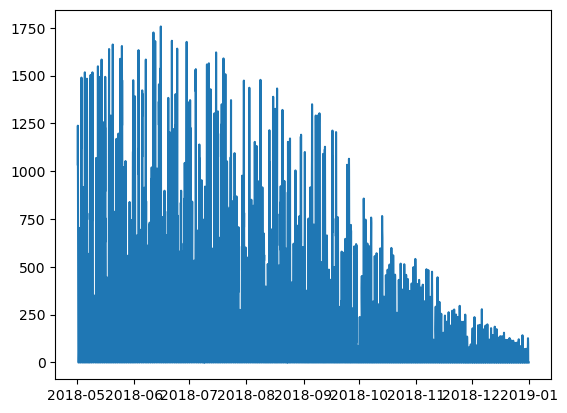

In [2]:
#create FULL light timeseries here
import numpy as np
import scipy
import scipy.integrate
import matplotlib.pyplot as plt
import pyreadr
import pandas as pd
import sympy as sp

import nbimporter
import NP_timeseries_wCERES
import cmocean as cm

%run NP_timeseries_wCERES.ipynb


In [3]:
start_time = pd.Timestamp('2018-05-01 09:00:00', tz='US/Alaska')
end_time = pd.Timestamp('2018-12-31 23:59:00', tz='US/Alaska')


In [4]:
light_data_2018

,time,approxPAR
0,2018-05-01 15:00:00-08:00,NaN
1,2018-05-01 16:00:00-08:00,1035.6077
2,2018-05-01 17:00:00-08:00,1238.0130
3,2018-05-01 18:00:00-08:00,1047.3983
4,2018-05-01 19:00:00-08:00,646.5179
...,...,...
5854,2018-12-31 20:00:00-09:00,0.0000
5855,2018-12-31 20:00:00-09:00,0.0000
5856,2018-12-31 22:00:00-09:00,0.0000
5857,2018-12-31 22:00:00-09:00,0.0000


In [5]:
#load in TS timeseries: convert to AK time and correct indices!
TS_data_2015_2018 = pd.read_csv('/Users/anjalishah/Desktop/Senior_Thesis/Data/fixed_mooring_T_S_2015_2018.csv')
TS_data_2015_2018['time'] = pd.to_datetime(TS_data_2015_2018['time'])
TS_data_2015_2018['time'] = TS_data_2015_2018['time'].dt.tz_localize('UTC', ambiguous='NaT')
TS_data_2015_2018['time']= TS_data_2015_2018['time'].dt.tz_convert('US/Alaska')

TS_data_2018 = TS_data_2015_2018[(TS_data_2015_2018['time'] >= start_time) & (TS_data_2015_2018['time'] <= end_time)] #filter data for correct dates (summer through fall)
TS_data_2018 = TS_data_2018[(TS_data_2018['depth']==15)] #had to use 15 meters since this was the only depth with full timeseries!

TS_data_2018.drop('Unnamed: 0', axis=1, inplace=True)
TS_data_2018.set_index(np.arange(0, len(TS_data_2018)), inplace=True)
TS_data_2018['time'] = TS_data_2018['time'].dt.round('H', ambiguous=True)


/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_4237/2401951794.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  TS_data_2015_2018['time'] = pd.to_datetime(TS_data_2015_2018['time'])
/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_4237/2401951794.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  TS_data_2018['time'] = TS_data_2018['time'].dt.round('H', ambiguous=True)


In [6]:
#full chlorophyll timeseries 
#convert to AK time 
chl_data_2018 = pd.read_csv('/Users/anjalishah/Desktop/Senior_Thesis/Data/18bsm2_0011m_chl_2018.csv', header=2)
chl_data_2018['time'] = pd.to_datetime(chl_data_2018['time'], format='%m/%d/%y %H:%M')
chl_data_2018['time'] = chl_data_2018['time'].dt.tz_localize('UTC')
chl_data_2018 = chl_data_2018.dropna(subset=['time'])
chl_data_2018['time'] = chl_data_2018['time'].dt.tz_convert('US/Alaska')
chl_data_2018 = chl_data_2018[(chl_data_2018['time'] >= start_time) & (chl_data_2018['time'] <= end_time)]
chl_data_2018.set_index(np.arange(0, len(chl_data_2018)), inplace=True)
chl_data_2018['time'] = chl_data_2018['time'].dt.round('H', ambiguous=True)



/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_4237/3847014378.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  chl_data_2018['time'] = chl_data_2018['time'].dt.round('H', ambiguous=True)


In [7]:
light_data_2018 = light_data_2018.dropna(subset=['time'])
light_data_2018.set_index(np.arange(0, len(light_data_2018)), inplace=True)
light_data_2018['time'] = light_data_2018['time'].dt.round('H', ambiguous=True)

/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_4237/1332439080.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  light_data_2018['time'] = light_data_2018['time'].dt.round('H', ambiguous=True)


In [8]:
light_data_2018

,time,approxPAR
0,2018-05-01 15:00:00-08:00,NaN
1,2018-05-01 16:00:00-08:00,1035.6077
2,2018-05-01 17:00:00-08:00,1238.0130
3,2018-05-01 18:00:00-08:00,1047.3983
4,2018-05-01 19:00:00-08:00,646.5179
...,...,...
5854,2018-12-31 20:00:00-09:00,0.0000
5855,2018-12-31 20:00:00-09:00,0.0000
5856,2018-12-31 22:00:00-09:00,0.0000
5857,2018-12-31 22:00:00-09:00,0.0000


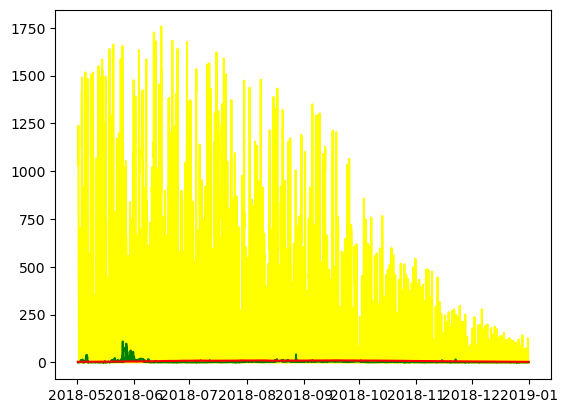

In [9]:
#ensure the timeseries look normal 
plt.plot(light_data_2018['time'], light_data_2018['approxPAR'], color='yellow')
plt.plot(chl_data_2018['time'], chl_data_2018[' ugrams/l'], color='green')
plt.plot(TS_data_2018['time'], TS_data_2018['temperature'], color='red')

In [10]:
TS_data_2018


,time,depth,temperature,salinity,season
0,2018-05-01 09:00:00-08:00,15,3.6514,NaN,summer
1,2018-05-01 10:00:00-08:00,15,3.4909,NaN,summer
2,2018-05-01 11:00:00-08:00,15,3.4623,NaN,summer
3,2018-05-01 12:00:00-08:00,15,3.2874,NaN,summer
4,2018-05-01 13:00:00-08:00,15,3.3350,NaN,summer
...,...,...,...,...,...
5872,2018-12-31 20:00:00-09:00,15,3.2960,NaN,winter
5873,2018-12-31 21:00:00-09:00,15,3.3240,NaN,winter
5874,2018-12-31 22:00:00-09:00,15,3.3320,NaN,winter
5875,2018-12-31 23:00:00-09:00,15,3.3380,NaN,winter


In [11]:
light_data_2018

,time,approxPAR
0,2018-05-01 15:00:00-08:00,NaN
1,2018-05-01 16:00:00-08:00,1035.6077
2,2018-05-01 17:00:00-08:00,1238.0130
3,2018-05-01 18:00:00-08:00,1047.3983
4,2018-05-01 19:00:00-08:00,646.5179
...,...,...
5854,2018-12-31 20:00:00-09:00,0.0000
5855,2018-12-31 20:00:00-09:00,0.0000
5856,2018-12-31 22:00:00-09:00,0.0000
5857,2018-12-31 22:00:00-09:00,0.0000


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Area after normalization: 50.000000
Area before normalization: 162.429512


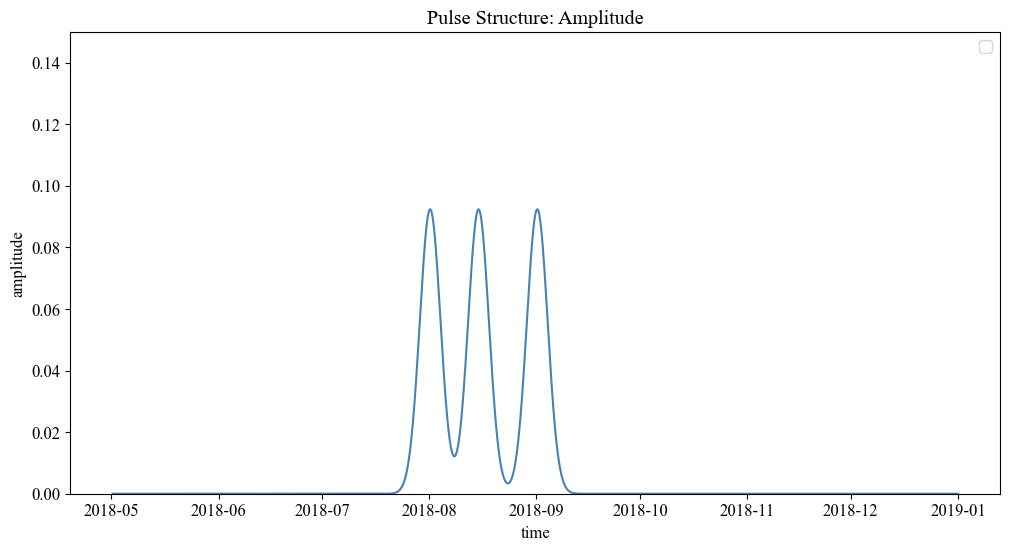

In [267]:
#pulse set up 
def gaussian(t, center, amp, width): 
    return amp * np.exp(-(t-center)**2 / (2*width**2))

# # #select forcing 

# # #forcing 1: 3 small storms 
# # # gaussian(TS_data_2018.index, 2949, 0.3, 24) + gaussian(TS_data_2018.index, 3669, 0.3, 24) + gaussian(TS_data_2018.index, 4400, 0.3, 24) 

# # #forcing 2: abundant storms: 
# # Forcing_plotted =  gaussian(TS_data_2018.index, 1797, 0.3, 72) + gaussian(TS_data_2018.index, 2949, 0.3, 72) + gaussian(TS_data_2018.index, 3285, 0.3, 72) + gaussian(TS_data_2018.index, 3669, 0.3, 72) + gaussian(TS_data_2018.index, 3992, 0.3, 72) + gaussian(TS_data_2018.index, 4400, 0.5, 96) 
# # plt.figure(figsize=(12,6))
# # plt.plot(TS_data_2018.time, Forcing_plotted, color='steelblue', label = 'after')
# # plt.title('Bloom Regime: Pulse')
# # plt.xlabel('time')
# # #early fall bloom pulses:
# # #hybrid forcing: gaussian(TS_data_2018.index, 2205, 0.3, 24) + gaussian(TS_data_2018.index, 2301, 0.3, 24) + gaussian(TS_data_2018.index, 2421, 0.5, 72) 
# # #Null hypothesis: gaussian(TS_data_2018.index, 2205, 0.3, 72) + gaussian(TS_data_2018.index, 2541, 0.3, 72) + gaussian(TS_data_2018.index, 2949, 0.3, 72) 
# # #frequency forcing:  gaussian(TS_data_2018.index, 2205, 0.3, 72) + gaussian(TS_data_2018.index, 2301, 0.3, 72) + gaussian(TS_data_2018.index, 2421, 0.3, 72) 
# # # stddev forcing: gaussian(TS_data_2018.index, 2205, 0.3, 144) + gaussian(TS_data_2018.index, 2541, 0.3, 144) + gaussian(TS_data_2018.index, 2949, 0.3, 144) 
# # # amplitude forcing: gaussian(TS_data_2018.index, 2205, 0.6, 72) + gaussian(TS_data_2018.index, 2541, 0.6, 72) + gaussian(TS_data_2018.index, 2949, 0.6, 72) 

# #NULL HYPOTHESIS normalization 

# Forcing_plotted = gaussian(TS_data_2018.index, 2205, 0.15, 72) + gaussian(TS_data_2018.index, 2541, 0.15, 72) + gaussian(TS_data_2018.index, 2949, 0.15, 72) 
# plt.figure(figsize=(12,6))
# #plt.plot(TS_data_2018.time, Forcing_plotted, color='steelblue', label='before')
# # Calculate the area under the curve 
# # Step size (assuming uniform spacing) 
# total_area =np.sum(Forcing_plotted) * dt 
# # # Normalize to make area = 25 --> SF = 25/81.214756 
# Forcing_normalized = (Forcing_plotted / total_area) * 25
# # Verify the area is now 25 
# check_area = np.sum(Forcing_normalized) * dt 
# plt.plot(TS_data_2018.time, Forcing_normalized, color='steelblue')
# plt.legend()
# plt.ylabel('Amplitude')
# plt.xlabel('time')
# plt.title('Pulse Structure: Null Hypothesis')
# plt.ylim([0, 0.15])
# print(f"Area after normalization: {check_area:.6f}")
# check_area = np.sum(Forcing_plotted) * dt 
# print(f"Area before normalization: {check_area:.6f}")
# plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/experiments/nullhypothesis_pulse_structure.jpg', dpi=300, bbox_inches='tight')


# # # # #frequency forcing 
# Forcing_plotted = gaussian(TS_data_2018.index, 2205, 0.15, 72) + gaussian(TS_data_2018.index, 2301, 0.15, 72) + gaussian(TS_data_2018.index, 2421, 0.15, 72) 
# # Calculate the area under the curve 
# dt = TS_data_2018.index[1] - TS_data_2018.index[0]  
# # Step size (assuming uniform spacing) 
# total_area =np.sum(Forcing_plotted) * dt 
# # # Normalize to make area = 25 --> SF = 25/81.214756
# Forcing_normalized = (Forcing_plotted / total_area) * 25
# # Verify the area is now 25 
# check_area = np.sum(Forcing_normalized) * dt 
# print(f"Area after normalization: {check_area:.6f}")
# check_area = np.sum(Forcing_plotted) * dt 
# print(f"Area before normalization: {check_area:.6f}")


# plt.figure(figsize=(12,6))
# #plt.plot(TS_data_2018.time, Forcing_plotted, color='steelblue', label='before')
# plt.plot(TS_data_2018.time, Forcing_normalized, color='steelblue')
# plt.legend()
# plt.ylabel('Amplitude')
# plt.xlabel('time')
# plt.title('Pulse Structure: Frequency')
# plt.ylim([0, 0.15])
# plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/experiments/frequency_pulse_structure.jpg', dpi=300, bbox_inches='tight')


# # #stddev/duration forcing 

# Forcing_plotted = gaussian(TS_data_2018.index, 2205, 0.15, 144) + gaussian(TS_data_2018.index, 2541, 0.15, 144) + gaussian(TS_data_2018.index, 2949, 0.15, 144) 
# # Calculate the area under the curve 
# dt = TS_data_2018.index[1] - TS_data_2018.index[0]  
# # Step size (assuming uniform spacing) 
# total_area =np.sum(Forcing_plotted) * dt 
# # # Normalize to make area = 100 --> SF = 25/162.429512
# Forcing_normalized = (Forcing_plotted / total_area) * 25
# # Verify the area is now 25 
# check_area = np.sum(Forcing_normalized) * dt 
# print(f"Area after normalization: {check_area:.6f}")
# check_area = np.sum(Forcing_plotted) * dt 
# print(f"Area before normalization: {check_area:.6f}")


# plt.figure(figsize=(12,6))
# #plt.plot(TS_data_2018.time, Forcing_plotted, color='steelblue', label='before')
# plt.plot(TS_data_2018.time, Forcing_normalized, color='steelblue', label = 'after')
# plt.legend()
# plt.title('Pulse Structure: Duration')
# plt.ylabel('Amplitude')
# plt.xlabel('time')
# plt.ylim([0,0.15])
# plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/experiments/duration_pulse_structure.jpg', dpi=300, bbox_inches='tight')


# # #amplitude forcing

Forcing_plotted = gaussian(TS_data_2018.index, 2205, 0.3, 72) + gaussian(TS_data_2018.index, 2541, 0.3, 72) + gaussian(TS_data_2018.index, 2949, 0.3, 72) 
# Calculate the area under the curve 
dt = TS_data_2018.index[1] - TS_data_2018.index[0]  
# Step size (assuming uniform spacing) 
total_area =np.sum(Forcing_plotted) * dt 
# # Normalize to make area = 100 --> SF = 50/162.429512, double normalization value
Forcing_normalized = (Forcing_plotted / total_area) * 50
# Verify the area is now 100 
check_area = np.sum(Forcing_normalized) * dt 
print(f"Area after normalization: {check_area:.6f}")
check_area = np.sum(Forcing_plotted) * dt 
print(f"Area before normalization: {check_area:.6f}")


plt.figure(figsize=(12,6))
#plt.plot(TS_data_2018.time, Forcing_plotted, color='steelblue', label='before')
plt.plot(TS_data_2018.time, Forcing_normalized, color='steelblue')
plt.legend()
plt.title('Pulse Structure: Amplitude')
plt.ylabel('amplitude')
plt.xlabel('time')
plt.ylim([0,0.15])
plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/experiments/amplitude_pulse_structure.jpg', dpi=300, bbox_inches='tight')

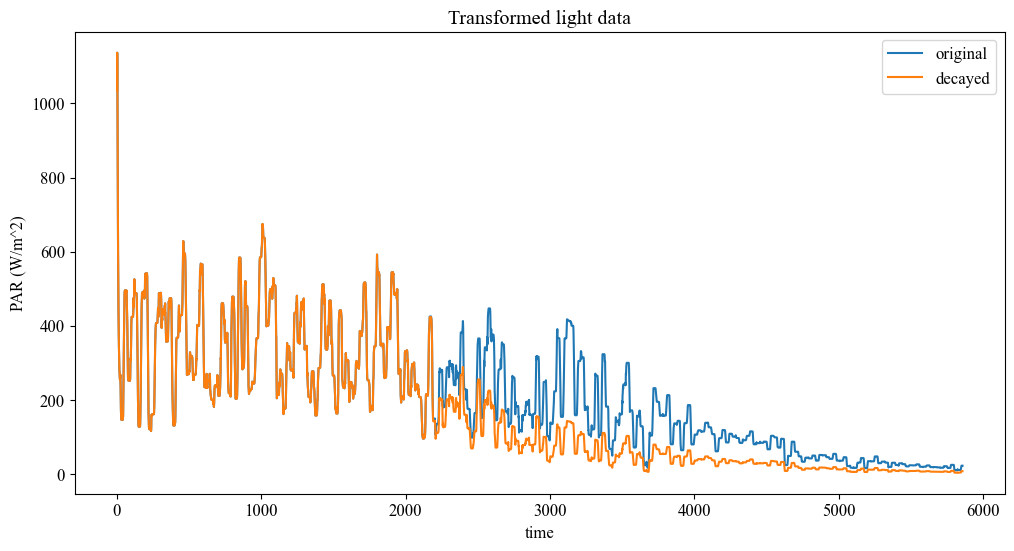

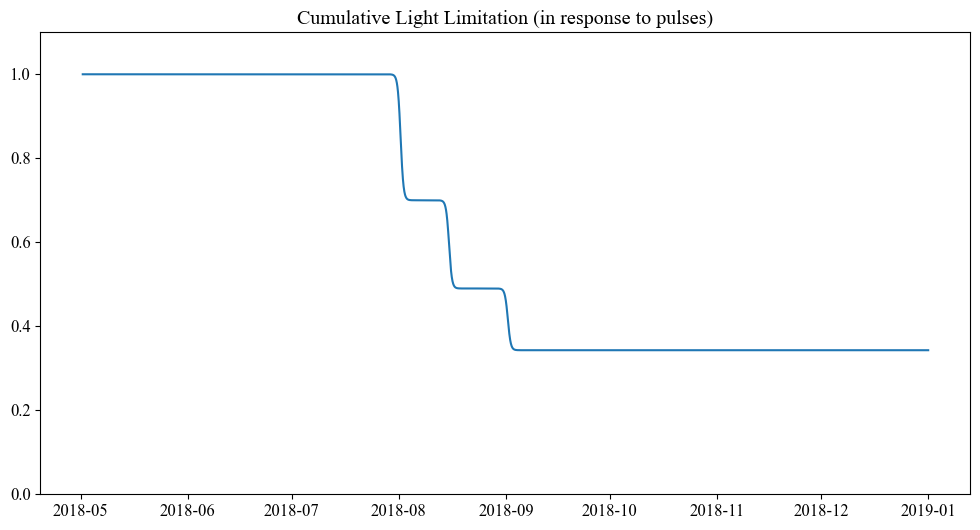

In [246]:
strat_index = 0.5
#step function set up: relates LIGHT to nutrient pulses through implicit transformation of Mixed Layer Depth! 

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12 

light_data_2018 #original data
# function goes between 0 and 0.5 (each pulse halves the light levels) --> just a guess, would depend on empirical relationship --> also should depend on amplitude of gaussian!!
#steepness represents slope between 1 and 0.5 --> would depend on empirical relationship
# hours = index of M2 timeseries
# threshold_hours = time of given pulse 

def create_tanh_decay(threshold_hours, hours, original_data, steepness=0.05): #change strat_index here --> so that storms disturb MLD more even if they are small in magnitude 
    """
    Creates a decay function that:
    - Returns 1 before threshold_hours
    - Smoothly transitions from 1 to 0.5 after threshold_hours using tanh
    
    Args:
        threshold_hours (float): Hours after which decay begins
        steepness (float): Controls how quickly the transition happens
    
    Returns:
        function: A function that takes hours as input and returns the decay factor
    """# Shift and scale tanh to get desired range [1.0, 0.5], # tanh goes from -1 to 1, so we scale and shift to go from 1 to 0.5
    #what we want: low strat = low number (close to zero), high strat = high number (close to 1). 
    # low strat = bigger storm disturbances with less wind, high strat = smaller storm disturbances with more wind!! --> strat held constant during pulsing experiments! 
    if 0 < strat_index < 0.25:
        if threshold_hours < 2205:
            decay_function =1 
        elif threshold_hours <= 3992:  # if threshold is before October 15th, reduce light by 50% (small storms)
            decay_function = 0.75 - 0.25 * np.tanh(steepness * (hours - threshold_hours))
        
        else: #if threshold is after this, reduce light by 70% (large storms)
            decay_function =0.65 - 0.35 * np.tanh(steepness * (hours - threshold_hours)) 
    elif 0.25 < strat_index < 0.5: 
        if threshold_hours < 2205:
            decay_function =1 
        elif threshold_hours <= 3992:  # if threshold is before October 15th, reduce light by 40% (small storms)
            decay_function = 0.8 - 0.2 * np.tanh(steepness * (hours - threshold_hours))
        else: #if threshold is after this, reduce light by 60% (large storms)
            decay_function = 0.7 - 0.3 * np.tanh(steepness * (hours - threshold_hours))
    elif 0.5 <= strat_index < 0.75: #avg strat conditions = 0.5 
        if threshold_hours < 2205:
            decay_function =1 
        elif threshold_hours <= 3992:  # if threshold is before October 15th, reduce light by 30% (small storms)
            decay_function = 0.85 - 0.15 * np.tanh(steepness * (hours - threshold_hours))
        else: #if threshold is after this, reduce light by 50% (large storms)
            decay_function = 0.75 - 0.25 * np.tanh(steepness * (hours - threshold_hours))
    else: #stratification conditions!!
        if threshold_hours < 2205:
            decay_function =1 
        elif threshold_hours <= 3992:  # if threshold is before October 15th, reduce light by 20% (small storms)
            decay_function = 0.95 - 0.05 * np.tanh(steepness * (hours - threshold_hours))
        else: #if threshold is after this, reduce light by 40% (large storms)
            decay_function = 0.8 - 0.2 * np.tanh(steepness * (hours - threshold_hours)) #notice that this is the same condition as small storms with super low stratification!
    decayed_data = original_data * decay_function
    return decayed_data, decay_function


#modified light function
# code for abundant pulses --> 4 small, 1 large
# decayed_data_one, decay_function_one = create_tanh_decay(2949, light_data_2018.index, light_data_2018['approxPAR'])
# decayed_data_two, decay_function_two = create_tanh_decay(3285, decayed_data_one.index, decayed_data_one)
# decayed_data_three, decay_function_three = create_tanh_decay(3669, decayed_data_two.index, decayed_data_two)
# decayed_data_four, decay_function_four = create_tanh_decay(3992, decayed_data_three.index, decayed_data_three)
# decayed_data_five, decay_function_five = create_tanh_decay(4400, decayed_data_four.index, decayed_data_four)
# decayed_data_six, decay_function_six = create_tanh_decay(1797, decayed_data_five.index, decayed_data_five)

#code for abundant pulses --> 3 small, 2 large
#decayed_data_one, decay_function_one = create_tanh_decay(3285, light_data_2018.index, light_data_2018['approxPAR'])
#decayed_data_two, decay_function_two = create_tanh_decay(3669, decayed_data_one.index, decayed_data_one)
#decayed_data_three, decay_function_three = create_tanh_decay(3992, decayed_data_two.index, decayed_data_two)
#decayed_data_four, decay_function_four = create_tanh_decay(4400, decayed_data_three.index, decayed_data_three)
#decayed_data_five, decay_function_five = create_tanh_decay(4747, decayed_data_four.index, decayed_data_four)

#early fall bloom pulses

#NULL HYPOTHESIS 
# decayed_data_one, decay_function_one = create_tanh_decay(2205, light_data_2018.index, light_data_2018['approxPAR'])
# decayed_data_two, decay_function_two = create_tanh_decay(2541, decayed_data_one.index, decayed_data_one)
# decayed_data_three, decay_function_three = create_tanh_decay(2949, decayed_data_two.index, decayed_data_two)

#IDEAL / HYBRID
#decayed_data_one, decay_function_one = create_tanh_decay(2205, light_data_2018.index, light_data_2018['approxPAR'])
#decayed_data_two, decay_function_two = create_tanh_decay(2301, decayed_data_one.index, decayed_data_one)
#decayed_data_three, decay_function_three = create_tanh_decay(2421, decayed_data_two.index, decayed_data_two)

#FREQUENCY 
# decayed_data_one, decay_function_one = create_tanh_decay(2205, light_data_2018.index, light_data_2018['approxPAR'])
# decayed_data_two, decay_function_two = create_tanh_decay(2301, decayed_data_one.index, decayed_data_one)
# decayed_data_three, decay_function_three = create_tanh_decay(2541, decayed_data_two.index, decayed_data_two)

#DURATION
# decayed_data_one, decay_function_one = create_tanh_decay(2205, light_data_2018.index, light_data_2018['approxPAR'])
# decayed_data_two, decay_function_two = create_tanh_decay(2541, decayed_data_one.index, decayed_data_one)
# decayed_data_three, decay_function_three = create_tanh_decay(2949, decayed_data_two.index, decayed_data_two)

#AMPLITUDE
decayed_data_one, decay_function_one = create_tanh_decay(2205, light_data_2018.index, light_data_2018['approxPAR'])
decayed_data_two, decay_function_two = create_tanh_decay(2541, decayed_data_one.index, decayed_data_one)
decayed_data_three, decay_function_three = create_tanh_decay(2949, decayed_data_two.index, decayed_data_two)

## plt.figure()
# plt.plot(light_data_2018['approxPAR'].rolling(24, min_periods=1).mean())
# plt.plot(decayed_data_five.rolling(24, min_periods=1).mean())
# plt.legend(['original','decayed'])
# plt.title('Transformed light data')
# plt.xlabel('time')
# plt.ylabel('PAR (W/m^2)')

# plt.figure(figsize=(12, 6))
# plt.plot(light_data_2018['time'], decay_function_one*decay_function_two*decay_function_three*decay_function_four*decay_function_five)
# plt.title('Cumulative Light Limitation (in response to pulses)')


#code for sparse  pulses --> need to modify tanh function here!

#decayed_data_one, decay_function_one = create_tanh_decay(2949, light_data_2018.index, light_data_2018['approxPAR'])
#decayed_data_two, decay_function_two = create_tanh_decay(3669, decayed_data_one.index, decayed_data_one)
#decayed_data_three, decay_function_three = create_tanh_decay(4400, decayed_data_two.index, decayed_data_two)

plt.figure(figsize=(12,6))
plt.plot(light_data_2018['approxPAR'].rolling(24, min_periods=1).mean())
plt.plot(decayed_data_three.rolling(24, min_periods=1).mean())
plt.legend(['original','decayed'])
plt.title('Transformed light data')
plt.xlabel('time')
plt.ylabel('PAR (W/m^2)')
plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/baseline testing/abundant_pulsed_lighttrans.jpg', dpi=300, bbox_inches='tight')

plt.figure(figsize=(12, 6))
plt.plot(light_data_2018['time'], decay_function_one*decay_function_two*decay_function_three)
plt.ylim([0,1.1])
plt.title('Cumulative Light Limitation (in response to pulses)')

plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/baseline testing/abundant_pulsed_cum_light_lim.jpg', dpi=300, bbox_inches='tight')


In [247]:
light_data_mod_pulses = pd.DataFrame({
        'time': light_data_2018.time,
        'approxPAR': decayed_data_three
    })

In [248]:
print(light_data_mod_pulses['time'].dtype)
print(chl_data_2018['time'].dtype)
print(TS_data_2018['time'].dtype)

print(light_data_mod_pulses['time'].dt.tz)
print(chl_data_2018['time'].dt.tz)
print(TS_data_2018['time'].dt.tz)

print(light_data_mod_pulses['time'].min(), light_data_mod_pulses['time'].max())
print(chl_data_2018['time'].min(), chl_data_2018['time'].max())
print(TS_data_2018['time'].min(), TS_data_2018['time'].max())

datetime64[ns, US/Alaska]
datetime64[ns, US/Alaska]
datetime64[ns, US/Alaska]
US/Alaska
US/Alaska
US/Alaska
2018-05-01 15:00:00-08:00 2018-12-31 23:00:00-09:00
2018-05-01 13:00:00-08:00 2018-12-31 23:00:00-09:00
2018-05-01 09:00:00-08:00 2019-01-01 00:00:00-09:00


In [249]:
M2_2018_all = pd.merge(light_data_mod_pulses, chl_data_2018, on='time', how='inner') #add in pulsed light, right now we have original light since there are no pulses
M2_2018_all = pd.merge(M2_2018_all, TS_data_2018, on='time', how='inner')
I=(pd.DataFrame((M2_2018_all['approxPAR'].fillna(method='bfill')))) #backfill NaNs
I = I.mul(0.5) #scale by 0.5 because we have surface irradiance values

T = pd.DataFrame(M2_2018_all['temperature'].fillna(method='bfill')) #define temp function as temp data from M2

#interpolate
time_eval = np.linspace(0, len(M2_2018_all)-1, len(M2_2018_all)) #create values to interpolate along
I_interp = scipy.interpolate.interp1d(time_eval, I['approxPAR'], kind='linear', fill_value = 'extrapolate')
T_interp = scipy.interpolate.interp1d(time_eval, T['temperature'], kind='linear', fill_value = 'extrapolate')

/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_4237/2840230099.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  I=(pd.DataFrame((M2_2018_all['approxPAR'].fillna(method='bfill')))) #backfill NaNs
/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_4237/2840230099.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  T = pd.DataFrame(M2_2018_all['temperature'].fillna(method='bfill')) #define temp function as temp data from M2


In [250]:
mu = .06 #phyto max growth rate / hr-1 --> Jin et. al 
r = .0633 #temp coefficient deg-1 -->  Jin et. al 
r_g = .03 #temp coefficient deg-1 -->  Jin et. al 
R_g_0 = 9.23e-4 #max mortality rate at 0 degrees (h-1) -->  Jin et. al 
Vmax = 1e-5 #max nitrogen uptake rate (NO3 and NH4) -->  fNO3 in Jin et. al, defined as Vmax in Eslinger et. al ?? confused here... 
#fNO3 = .01 #from Jin et. al, maybe this is wrong, unsure????
alpha = .05 # light --> photosynthesis conversion rate, mgC / [mg Chla h W m2] --> Eslinger et. al 
#beta = 0 #photoinhibition coefficient mg C /(mg Chla h W m2) --> Eslinger et. al 
P_B_S = 3.25 #max photosynthesis rate, mcg C/(mgChlhr) --> Eslinger et. al 
k_s = 1.0 #MM half staturation constant, change to get small versus large cells!!!
k_N_chl = .4848 #converts mg-Chl to mmol N
#gamma_D = .006 #(h-1), averaged over: S, L, P (diff zooplankton types) -->  Jin et. al 
#gamma_F = .087 #(h-1), averaged over: S, L, P (diff zooplankton types) -->  Jin et. al 
#photo_slope = .055 #initial photosynthetic slope -->  Jin et. al 

In [251]:
#photosynthetic rate with irradiance -> create dimensionless value to compare with V_Frac

def P_B(I): 
    P_B = P_B_S*(1-(np.exp(-(alpha*I)/P_B_S)))*(np.exp((-beta*I)/P_B_S)) 
    P_frac = P_B/P_B_S
    return P_frac

def N_in(t):
    return 0.0208 # hr^-1 value from EPOC 2023 poster Pellend et. al --> entrainment approximation

def V_frac(N): #create dimensionless nitrogen value to compare with V_frac
    V_N = Vmax * (N/(N+k_s))
    if V_N < 0: 
        print(N)
    return V_N / Vmax 

In [252]:
#define rates function: here flagellate growth rates and diatom growth rates do not differ
def phyto_rates(T, N_frac, I_frac): 
    phyto_growth = mu * np.exp(r*T) * min(N_frac, I_frac) #growth, use minimum of dimensionless nitrogen and irradiance
    phyto_resp = .05 * mu * np.exp(r*T) #respiration
    phyto_mortality = R_g_0 * np.exp(r_g * T) #mortality
    return [phyto_growth, phyto_resp, phyto_mortality]

Index([2205], dtype='int64')
Index([2301], dtype='int64')
Index([2541], dtype='int64')
Index([3992, 3993], dtype='int64')
Index([4400, 4401], dtype='int64')
Index([4747], dtype='int64')
Index([5131], dtype='int64')
Index([5467], dtype='int64')
Index([5707], dtype='int64')


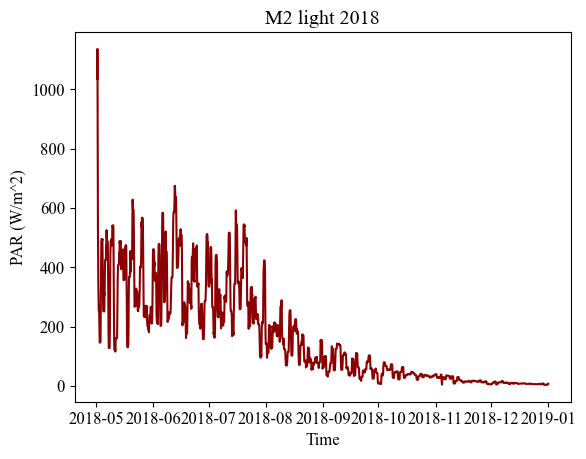

In [253]:
timestamp = M2_2018_all['time']
plt.plot(M2_2018_all.time, M2_2018_all['approxPAR'].rolling(24, min_periods=1).mean(), color='darkred')
plt.title('M2 light 2018')
plt.xlabel('Time')
plt.ylabel('PAR (W/m^2)')
plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/M2_light_2018.jpg', dpi=300, bbox_inches='tight')

#selection of pulse points: 
print(M2_2018_all[M2_2018_all['time'] == '2018-08-01 12:00:000'].index)
print(M2_2018_all[M2_2018_all['time'] == '2018-08-05 12:00:000'].index)
print(M2_2018_all[M2_2018_all['time'] == '2018-08-15 12:00:000'].index)
print(M2_2018_all[M2_2018_all['time'] == '2018-10-15 12:00:000'].index)
print(M2_2018_all[M2_2018_all['time'] == '2018-11-01 12:00:000'].index)
print(M2_2018_all[M2_2018_all['time'] == '2018-11-15 13:00:000'].index)
print(M2_2018_all[M2_2018_all['time'] == '2018-12-01 13:00:000'].index)
print(M2_2018_all[M2_2018_all['time'] == '2018-12-15 13:00:000'].index)
print(M2_2018_all[M2_2018_all['time'] == '2018-12-25 13:00:000'].index)

In [256]:
#define growth rate function: relates phytoplankton growth rate to temperature 
#define npz system
I_frac = [None] * len(time_eval)
N_frac = [None] * len(time_eval)
dP_stored = [None] * len(time_eval)
def npz(t, X): #this model takes in temperature, nutrients (N), and irradiance (I)
    [N, P] = X
    Temp = T_interp(t)
    I_value = I_interp(t)
    PBI = P_B(I_value) #calculate dimensionaless irradiance: I_frac
    V_frac_calc = V_frac(N) #calculate dimensionaless nutrients: N_frac
    if V_frac_calc < 0: 
        V_frac_calc = 0 
    if I_frac[round(t)] == None: #takes the first value, not the last! 
        I_frac[round(t)] = (P_B(I_value)) #store I_frac
        N_frac[round(t)] = (V_frac_calc) #store N_frac
    [phyto_growth, phyto_resp, phyto_mortality] = phyto_rates(Temp, V_frac_calc, PBI) #calculate phyto rates based on Temperature
    #abundant storms forcing 
    #F = (1/np.sqrt(strat_index)) * (gaussian(t, 1797, 0.3, 72) + gaussian(t, 2949, 0.3, 72) + gaussian(t, 3285, 0.3, 72) +  gaussian(t, 3669, 0.3, 72) + gaussian(t, 3992, 0.3, 72) + gaussian(t, 4400, 0.3, 96))
    #NULL HYPOTHESIS FORCING 
    SF = 25/81.214756 
    F = (1/np.sqrt(strat_index)) * (gaussian (t, 2205, 0.15, 72) + gaussian(t, 2541, 0.15, 72) +  gaussian(t, 2949, 0.15, 72)) * SF 
    #frequency forcing
    # SF = 25/81.214756
    # F = (1/np.sqrt(strat_index)) * (gaussian (t, 2205, 0.15, 72) + gaussian(t, 2301, 0.15, 72) +  gaussian(t, 2541, 0.15, 72)) *SF
    # std dev (duration) forcing
    # SF = 25/162.429512
    # F = (1/np.sqrt(strat_index)) * (gaussian(t, 2205, 0.15, 144) + gaussian(t, 2541, 0.15, 144) +  gaussian(t, 2949, 0.15, 144)) *SF
    #amplitude forcing 
    SF = 50/162.429512
    F = (1/np.sqrt(strat_index)) * (gaussian (t, 2205, 0.3, 72) + gaussian(t, 2541, 0.3, 72) +  gaussian(t, 2949, 0.3, 72))

    dN_dt = - (P*(phyto_growth-phyto_resp))*(k_N_chl) + N_in(t) + F
    #dN_dt = N + #create new function here!
    dP_dt = P*(phyto_growth-phyto_resp-(6*phyto_mortality)) #scale by 0.001 to reduce over-grazing
    if dP_stored[round(t)] == None:
        dP_stored[round(t)] = dP_dt #store dP_dt value 
    #print(PBI)
    #print(V_frac_calc)
    #print(phyto_mortality)
    #rho_t[round(t)] = I_value
    return [dN_dt, dP_dt]


In [257]:
#initial condtions 
N0 = 0.5
P0 = 0.5
init = [N0, P0]

#time range
time_eval = np.linspace(0, len(M2_2018_all)-1, len(M2_2018_all)) #create values to interpolate along
time = (0, len(M2_2018_all)-1)


In [258]:
M2_model = scipy.integrate.solve_ivp(npz, y0 = init, t_span = time, t_eval=time_eval, method='Radau', dense_output=False)

-0.2229272745925095
-0.17935595389971748
-0.2819693370880698
-0.2541157804578559
-0.28003191550196116
-0.46159847379646324
-0.6221598819666937
-0.13836434642007367
-0.08283353095603257
-0.0828241184316788
-0.1151450291921004
-0.45205311504921963
-0.11512466608610955
-0.45200330925723164
-0.22683373611011365
-0.5909967098130733
-0.015418786474009127
-0.015418786474009127
-0.12004896366235907
-0.09349363326513477
-0.07257300096802144
-0.10975649829954781
-0.0221695229201615
-0.012375513039980746
-0.01238907788982746
-0.06772861263609545
-0.0522160576586197
-0.11205778919432507
-0.11205778919432507
-0.7435466237952104
-0.7435466237952104
-0.8944694883409974
-0.8628284970508653
-0.38582138494813867
-0.008784197329095633
-0.22719132844449952
-0.22719132844449952
-0.6497092470920107
-0.1151830975107459
-0.1151830975107459
-0.7996608064513273
-0.7761051467092512
-0.8755901075949244
-0.8929473400350609
-0.3792912280538412
-0.9946452851522891
-0.9946486429120536
-0.03084942026520232
-0.93017969

90.1665605494729


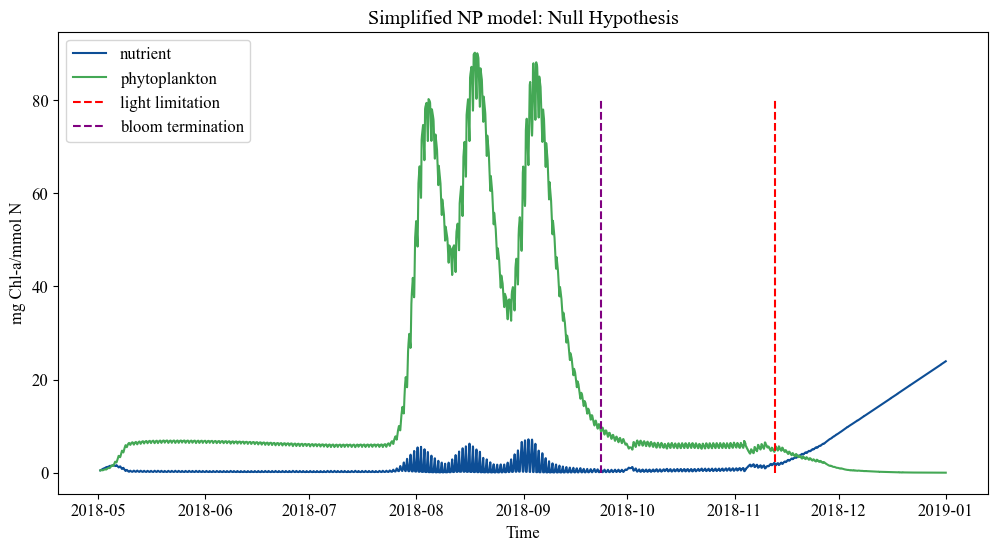

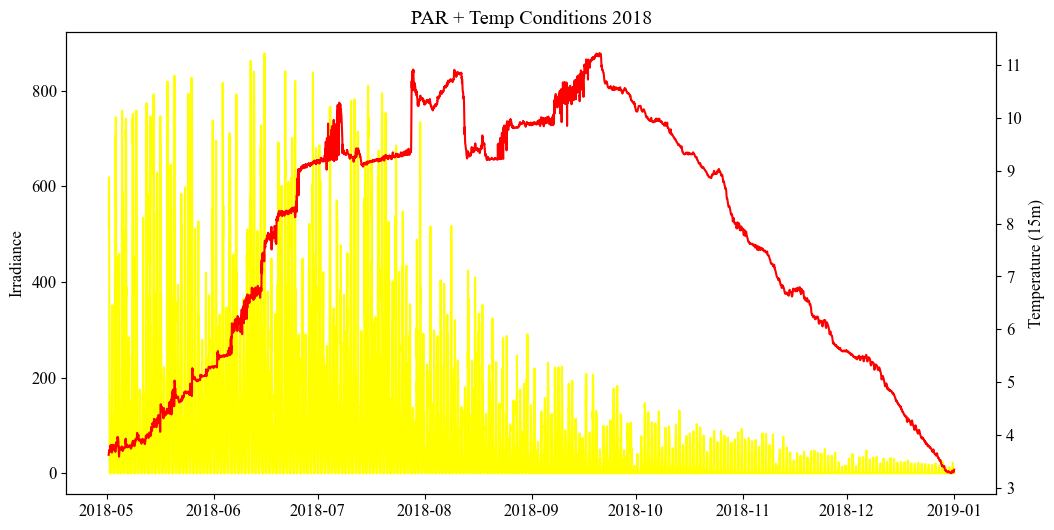

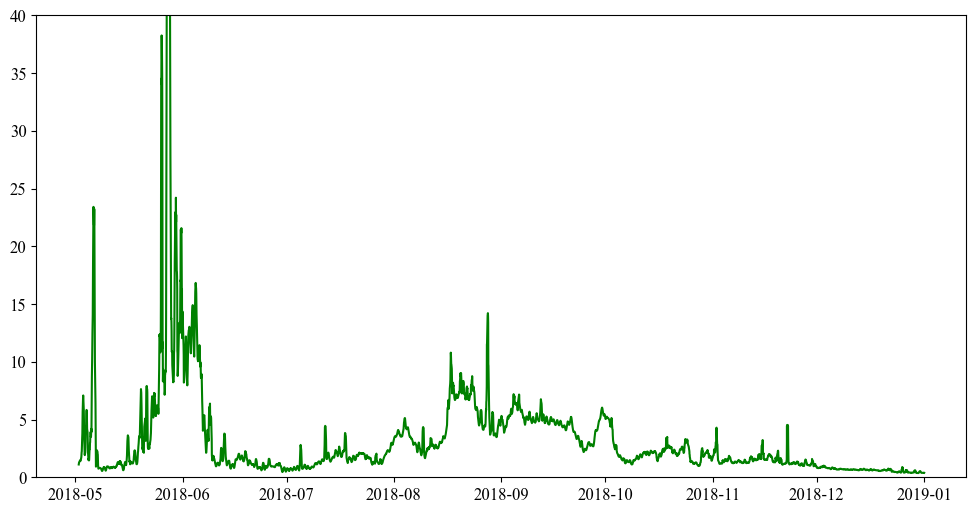

In [266]:
timestamp = M2_2018_all['time']
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12 

fig, ax4 = plt.subplots(figsize=(12, 6))  # Creates the figure

# Plot on ax4
ax4.plot(timestamp, M2_model.y[0], color='#0d4e96', label='nutrient')  # P
ax4.plot(timestamp, M2_model.y[1], color='#44a855', label='phytoplankton')  # P

# Add vertical lines
ax4.vlines(x=timestamp[first_occurrence], ymin=0, ymax=80, colors='r', linestyles='--', label='light limitation')
ax4.vlines(x=timestamp[first_negative_index], ymin=0, ymax=80, colors='purple', linestyles='--', label='bloom termination')

#ax5 = ax4.twinx()
#ax5.plot(TS_data_2018.time, Forcing_plotted, color='steelblue', label='nutrient forcing')

# Combine handles and labels from both ax4 and ax5 for the legend
handles, labels = ax4.get_legend_handles_labels()
#handles2, labels2 = ax5.get_legend_handles_labels()

# Combine the handles and labels
#handles.extend(handles2)
#labels.extend(labels2)

# Create the legend
plt.legend(handles, labels, loc='upper left')  # You can adjust the location as needed

plt.title('Simplified NP model: Null Hypothesis')
plt.xlabel('Time')
ax4.set_ylabel('mg Chl-a/mmol N')
#ax5.set_ylabel('mmol N/day')
plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/experiments/amplitude_output.jpg', dpi=300, bbox_inches='tight')

#plot environmental conditions
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(timestamp, I, color='yellow', label='Irradiance')
ax1.set_ylabel('Irradiance')
ax2 = ax1.twinx()
ax2.plot(timestamp, T, color='red', label='Temperature')
ax2.set_ylabel('Temperature (15m)')
plt.title('PAR + Temp Conditions 2018')
plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/PAR_temp_2018.jpg', dpi=300, bbox_inches='tight')


fig, ax3 = plt.subplots(figsize=(12, 6))
data_2023_M2 = pd.read_csv('/Users/anjalishah/Desktop/EcoFOCI2024/Data/Mooring_Sites/M2/22bs2c_ecf_0012m.csv')
ax3.plot(timestamp, M2_2018_all[' ugrams/l'].rolling(10).mean(), color='green', label='Chl-a 2018')
#ax3.plot(timestamp, np.log10(M2_2018_all[' ugrams/l'].rolling(10).mean()), color='green', label='Chl-a')
data_2023_M2['time (UTC)'] = pd.to_datetime(data_2023_M2['time (UTC)'])
ax3.set_ylim([0, 40])
#ax3.plot(data_2023_M2['time (UTC)'], (data_2023_M2['chlorophyll_fluorescence'].rolling(10).mean()), label='Chl-a 2022')
#ax3.set_ylabel('log(Chl-a)')
#ax3.set_xlabel('Time)')
#plt.title('Chlorophyll 2018 (11m)')
#plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/chl_a_2018.jpg', dpi=300, bbox_inches='tight')


print(np.max(M2_model.y[1]))


First negative value -0.0044749328236057115 occurs at 3474
2018-09-23 09:00:00-08:00


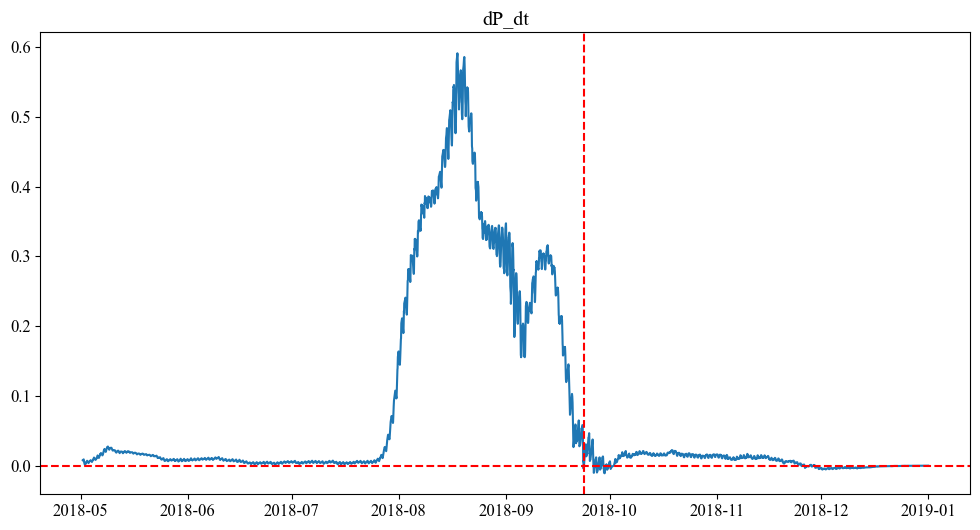

In [261]:
dP_series = pd.Series(dP_stored)


dP_smoothed = dP_series.rolling(400, min_periods=1).mean()
fig, ax4 = plt.subplots(figsize=(12, 6))
ax4.plot(timestamp, dP_smoothed)

max = np.max(dP_smoothed)
argmax = np.argmax(dP_smoothed)

dp_smoothed_postbloom = dP_smoothed[argmax:]

std = np.std(dp_smoothed_postbloom)
condition = dp_smoothed_postbloom < 0 #(max - 3*std)


if any(condition):  # Check if there are any negative values
    first_negative = dp_smoothed_postbloom[condition].iloc[0]
    first_negative_index = dp_smoothed_postbloom[condition].index[0]
    print(f"First negative value {first_negative} occurs at {first_negative_index}")
else:
    print("No negative values found")

ax4.axvline(x=timestamp[first_negative_index], color='r', linestyle='--', label='First Negative Value')
ax4.axhline(y=0, color='r', linestyle='--', label='First Negative Value')

print(timestamp[first_negative_index])
plt.title('dP_dt')
plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/dp_dt.jpg', dpi=300, bbox_inches='tight')



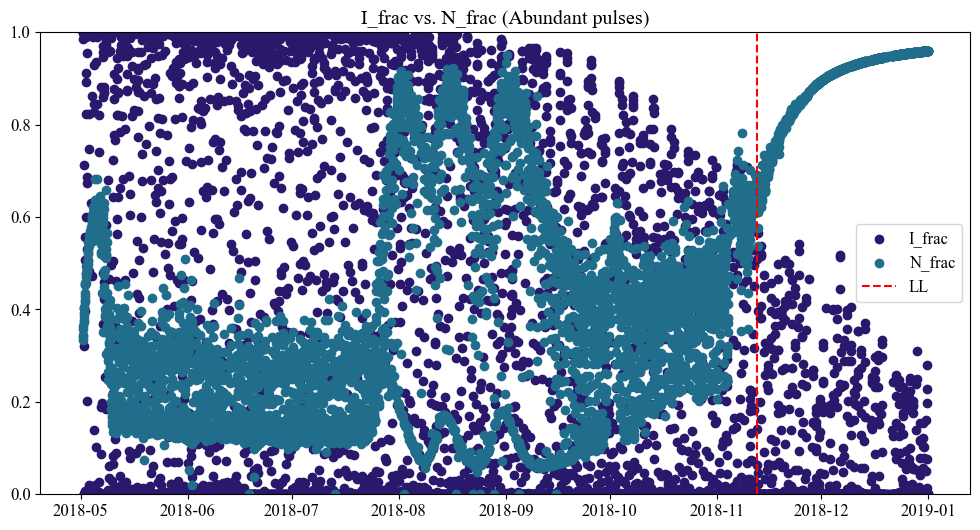

In [262]:
import matplotlib 
fig, ax4 = plt.subplots(figsize=(12, 6))
ax4.scatter(timestamp, I_frac, color = '#2a186c')
ax4.scatter(timestamp, N_frac, color = '#206e8b')
ax4.vlines(timestamp[first_occurrence],  ymin=0, ymax=1, colors='r', linestyles='--')
ax4.legend(['I_frac', 'N_frac', 'LL'], loc = 'center right')
ax4.set_ylim([0,1])
ax4.set_title('I_frac vs. N_frac (Abundant pulses)')
plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/baseline testing/N_frac_I_frac_timeseries_abundantpulses.jpg', dpi=300, bbox_inches='tight')

#colormaps --> create new one 
cmap = plt.get_cmap(cm.cm.haline)  # You can choose any colormap

# Number of discrete colors you want
num_colors = 3

# Get the discrete colors from the colormap
colors = [cmap(i / num_colors) for i in range(num_colors)]

# Convert the colors to hex codes
hex_colors = [matplotlib.colors.to_hex(color) for color in colors]


/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_4237/3147873410.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  I_frac_filled = I_frac.fillna(method='bfill').to_numpy()
/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_4237/3147873410.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  N_frac_filled = N_frac.fillna(method='bfill').to_numpy()


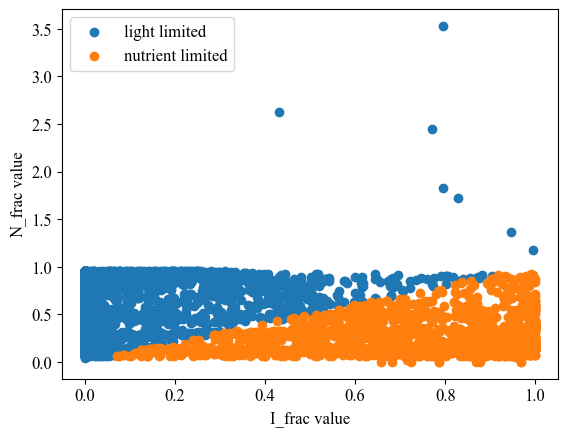

In [263]:
I_frac = pd.Series(I_frac)
N_frac = pd.Series(N_frac) #convert to series 

I_frac_filled = I_frac.fillna(method='bfill').to_numpy()
N_frac_filled = N_frac.fillna(method='bfill').to_numpy()

nut_limited = np.where(I_frac_filled > N_frac_filled)
light_limited = np.where(N_frac_filled > I_frac_filled)

nut_limited = np.array(nut_limited).squeeze()
light_limited = np.array(light_limited).squeeze()



plt.scatter(I_frac[light_limited], N_frac[light_limited])
plt.scatter(I_frac[nut_limited], N_frac[nut_limited])
plt.xlabel('I_frac value')
plt.ylabel('N_frac value')
plt.legend(['light limited', 'nutrient limited'])
plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/N_frac_I_frac.jpg', dpi=300, bbox_inches='tight')

First week long period of light limitation starts at: 2018-11-12 14:00:00-09:00


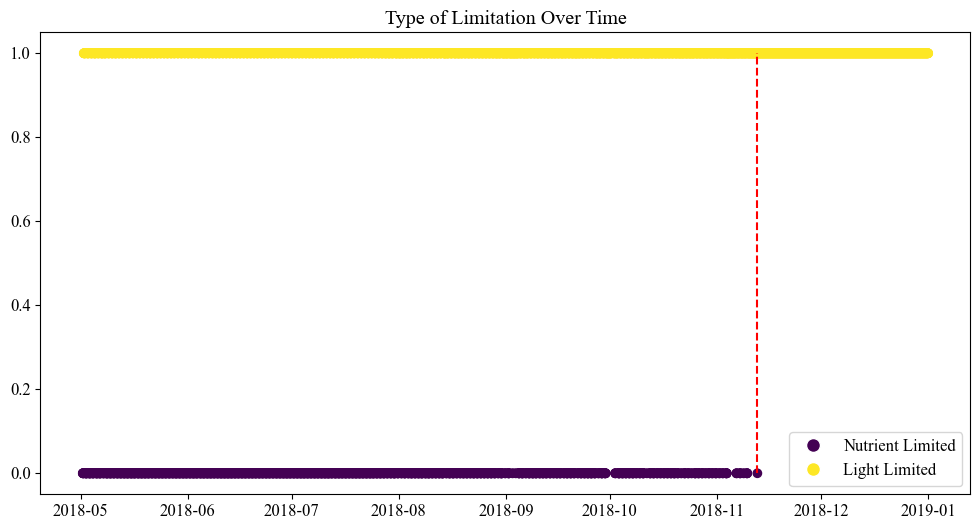

In [265]:
limitation_terms = np.ones_like(timestamp.index)

limitation_terms[nut_limited] = 0 #1 is light limited, 0 is nutrient limited

fig, ax5= plt.subplots(figsize=(12, 6))

scatter = ax5.scatter(timestamp, limitation_terms, c=limitation_terms, cmap='viridis')

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w',
                         markerfacecolor='#440154', label='Nutrient Limited', markersize=10),  # purple
                  Line2D([0], [0], marker='o', color='w',
                         markerfacecolor='#FDE725', label='Light Limited', markersize=10)]  # yellow

# Add the legend
ax5.legend(handles=legend_elements)

#Calculate when light limitation truly begins
# Convert numpy array to pandas Series
limitation_series = pd.Series(limitation_terms)

# Now we can use rolling window: 
w = 168
consecutive_ones = limitation_series.rolling(window=w).sum()

# Find where the sum equals 168
full_day_light_limited = consecutive_ones == w

# Find first occurrence
if any(full_day_light_limited):
    first_occurrence = full_day_light_limited[full_day_light_limited].index[0] - 168
    print(f"First week long period of light limitation starts at: {timestamp[first_occurrence]}")

#plot line 

ax5.vlines(timestamp[first_occurrence], ymin=0, ymax=1, colors='r', linestyles='--')
ax5.set_title('Type of Limitation Over Time')
plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/limitation_type.jpg', dpi=300, bbox_inches='tight')

In [652]:
limitation_terms

array([0, 0, 0, ..., 1, 1, 1])

In [653]:
nut_limited

array([   0,    1,    2, ..., 4263, 4285, 4286])

In [604]:
#parameter space: days between pulses vs. bloom magnitude 

#software --> change F with every repetition, save onset of light limitation variable (nothing else) --> plot relationship


#5,8, 11, 14, 17, 20 days between pulses
bloom_term= []
light_limited_series = []
bloom_magnitude = []
day_delta = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
hour_delta = [x*24 for x in day_delta]
for h in hour_delta: 
    #recalc light function: 3 tan decreases
    decayed_data_one, decay_function_one = create_tanh_decay(2205, light_data_2018.index, light_data_2018['approxPAR'])
    decayed_data_two, decay_function_two = create_tanh_decay(2205+h, decayed_data_one.index, decayed_data_one)
    decayed_data_three, decay_function_three = create_tanh_decay(2205+(2*h), decayed_data_two.index, decayed_data_two)
    light_data_mod_pulses = pd.DataFrame({
        'time': light_data_2018.time,
        'approxPAR': decayed_data_three
    })
    #define npz system
    I_frac = [None] * len(time_eval)
    N_frac = [None] * len(time_eval)
    dP_stored = [None] * len(time_eval)
    def npz(t, X): #this model takes in temperature, nutrients (N), and irradiance (I)
        [N, P] = X
        Temp = T_interp(t)
        I_value = I_interp(t)
        PBI = P_B(I_value) #calculate dimensionaless irradiance: 
        
        V_frac_calc = V_frac(N) #calculate dimensionaless nutrients: N_frac
        if V_frac_calc < 0: 
            V_frac_calc = 0 
        if I_frac[round(t)] == None: #takes the first value, not the last! 
            I_frac[round(t)] = (P_B(I_value)) #store I_frac
            N_frac[round(t)] = (V_frac_calc) #store N_frac
        [phyto_growth, phyto_resp, phyto_mortality] = phyto_rates(Temp, V_frac_calc, PBI) #calculate phyto rates based on Temperature
        #storm proximity forcing
        F = (1/np.sqrt(strat_index)) * (gaussian (t, 2205, 0.3, 72) + gaussian(t, 2205 + h, 0.3, 72) +  gaussian(t, 2205+(2*h), 0.3, 72))
        dN_dt = - (P*(phyto_growth-phyto_resp))*(k_N_chl) + N_in(t) + F
        #dN_dt = N + #create new function here!
        dP_dt = P*(phyto_growth-phyto_resp-(6*phyto_mortality)) #scale by 0.001 to reduce over-grazing
        if dP_stored[round(t)] == None:
            dP_stored[round(t)] = dP_dt #store dP_dt value 
        return [dN_dt, dP_dt]
    #initial condtions 
    N0 = 0.5
    P0 = 0.5
    init = [N0, P0]

    #time range
    time_eval = np.linspace(0, len(M2_2018_all)-1, len(M2_2018_all)) #create values to interpolate along
    time = (0, len(M2_2018_all)-1)
    #run model 
    M2_model = scipy.integrate.solve_ivp(npz, y0 = init, t_span = time, t_eval=time_eval, method='Radau', dense_output=False)

    #record bloom magnitude 
    bloom_magnitude.append(np.max(M2_model.y[1]))

    #calculate bloom termination
    dP_series = pd.Series(dP_stored)
    dP_smoothed = dP_series.rolling(475, min_periods=1).mean()

    if any(dP_smoothed < 0):
        first_negative = dP_smoothed[dP_smoothed < 0].iloc[0]
        first_negative_index = dP_smoothed[dP_smoothed < 0].index[0]
        print(f"First negative value {first_negative} occurs at {first_negative_index}")
    else:
        print("No negative values found")
    
    bloom_term.append(first_negative_index) #store bloom date
    
    #calculate light limitation
    I_frac = pd.Series(I_frac)
    N_frac = pd.Series(N_frac) #convert to series 

    I_frac_filled = I_frac.fillna(method='bfill').to_numpy()
    N_frac_filled = N_frac.fillna(method='bfill').to_numpy()

    nut_limited = np.where(I_frac_filled > N_frac_filled)
    light_limited = np.where(N_frac_filled > I_frac_filled)

    nut_limited = np.array(nut_limited).squeeze()
    light_limited = np.array(light_limited).squeeze()
    limitation_terms = np.ones_like(timestamp.index)

    limitation_terms[nut_limited] = 0 #1 is light limited, 0 is nutrient limited

    limitation_series = pd.Series(limitation_terms) #binary series

    # Now we can use rolling window: 
    w = 168
    consecutive_ones = limitation_series.rolling(window=w).sum()

    # Find where the sum equals 168
    full_day_light_limited = consecutive_ones == w

    # Find first occurrence
    if any(full_day_light_limited):
        first_occurrence = full_day_light_limited[full_day_light_limited].index[0]
        print(f"First week long period of light limitation starts at: {timestamp[first_occurrence]}")
    
    light_limited_series.append(first_occurrence) #store light date
    

-0.2229272745925095
-0.17935595389971748
-0.2819693370880698
-0.2541157804578559
-0.28003191550196116
-0.46159847379646324
-0.6221598819666937
-0.13836434642007367
-0.08283353095603257
-0.0828241184316788
-0.1151450291921004
-0.45205311504921963
-0.11512466608610955
-0.45200330925723164
-0.22683373611011365
-0.5909967098130733
-0.015418786474009127
-0.015418786474009127
-0.08987006118962562
-0.04895407631655663
-0.09293616081880879
-0.0720465525999825
-0.014327053078129925
-0.005218730452908049
-0.07720308550174113
-0.1308959737293947
-0.006255411698717905
-0.7198626926728116
-0.8317177347342497
-0.8317177347342497
-0.062250201635678515
-0.062250201635678515
-0.6683621982105805
-0.20361519581806053
-0.20361519581806053
-0.047768236621600124
-0.047768236621600124
-0.3427193705860567
-0.3427193705860567
-0.707105889350431
-0.707105889350431
-0.41406031200843807
-0.10160135221165412
-0.21638941520670607
-0.004666488415185688
-0.2808944585567321
-0.2409054494848064
-0.17797661160836142
-0.

KeyboardInterrupt: 

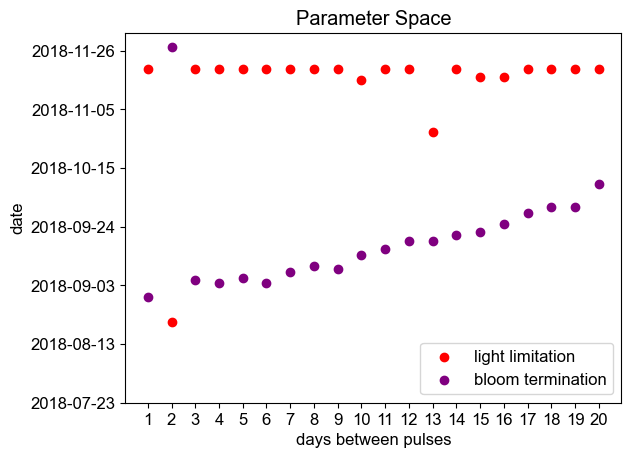

In [474]:
plt.scatter(day_delta, light_limited_series, color = 'red')
plt.scatter(day_delta, bloom_term, color = 'purple')
plt.yticks(ticks = [2000, 2500, 3000, 3500, 4000, 4500, 5000], labels = timestamp[[2000, 2500, 3000, 3500, 4000, 4500, 5000]].dt.date)
plt.xticks(ticks = day_delta)
plt.legend(['light limitation', 'bloom termination'], loc='lower right')
plt.title('Parameter Space')
plt.xlabel('days between pulses')
plt.ylabel('date')
plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/param_space.jpg', dpi=300, bbox_inches='tight')

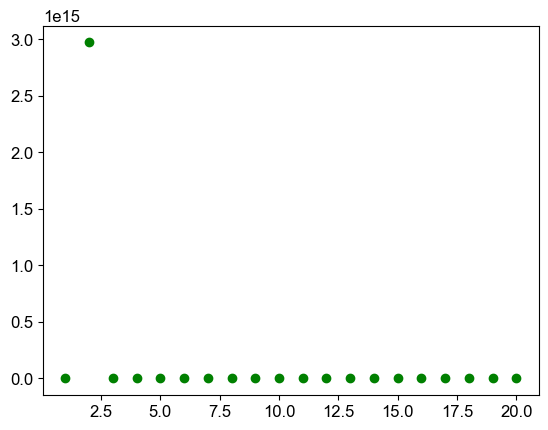

In [251]:
plt.scatter(day_delta, bloom_magnitude, color = 'green')

In [475]:
#parameter space: days between pulses vs. bloom magnitude 

#software --> change F with every repetition, save onset of light limitation variable (nothing else) --> plot relationship


#5,8, 11, 14, 17, 20 days between pulses
bloom_term= []
light_limited_series = []
bloom_magnitude = []
std_dev = [24, 48, 72, 96, 120, 144, 168]
for dev in std_dev: 
    #recalc light function: 3 tan decreases
    decayed_data_one, decay_function_one = create_tanh_decay(2205, light_data_2018.index, light_data_2018['approxPAR'])
    decayed_data_two, decay_function_two = create_tanh_decay(2541, decayed_data_one.index, decayed_data_one)
    decayed_data_three, decay_function_three = create_tanh_decay(2949, decayed_data_two.index, decayed_data_two)
    light_data_mod_pulses = pd.DataFrame({
        'time': light_data_2018.time,
        'approxPAR': decayed_data_three
    })
    #define npz system
    I_frac = [None] * len(time_eval)
    N_frac = [None] * len(time_eval)
    dP_stored = [None] * len(time_eval)
    def npz(t, X): #this model takes in temperature, nutrients (N), and irradiance (I)
        [N, P] = X
        Temp = T_interp(t)
        I_value = I_interp(t)
        PBI = P_B(I_value) #calculate dimensionaless irradiance: I_frac
        V_frac_calc = V_frac(N) #calculate dimensionaless nutrients: N_frac
        if V_frac_calc < 0: 
            V_frac_calc = 0 
        if I_frac[round(t)] == None: #takes the first value, not the last! 
            I_frac[round(t)] = (P_B(I_value)) #store I_frac
            N_frac[round(t)] = (V_frac_calc) #store N_frac
        [phyto_growth, phyto_resp, phyto_mortality] = phyto_rates(Temp, V_frac_calc, PBI) #calculate phyto rates based on Temperature
        #storm proximity forcing
        F = (1/np.sqrt(strat_index)) * (gaussian (t, 2205, 0.3, dev) + gaussian(t, 2541, 0.3, dev) +  gaussian(t, 2949, 0.3, dev))
        dN_dt = - (P*(phyto_growth-phyto_resp)) + N_in(t) + F
        #dN_dt = N + #create new function here!
        dP_dt = P*(phyto_growth-phyto_resp-(6*phyto_mortality)) #scale by 0.001 to reduce over-grazing
        if dP_stored[round(t)] == None:
            dP_stored[round(t)] = dP_dt #store dP_dt value 
        return [dN_dt, dP_dt]
    #initial condtions 
    N0 = 0.5
    P0 = 0.5
    init = [N0, P0]

    #time range
    time_eval = np.linspace(0, len(M2_2018_all)-1, len(M2_2018_all)) #create values to interpolate along
    time = (0, len(M2_2018_all)-1)
    #run model 
    M2_model = scipy.integrate.solve_ivp(npz, y0 = init, t_span = time, t_eval=time_eval, method='Radau', dense_output=False)

    #record bloom magnitude 
    bloom_magnitude.append(np.max(M2_model.y[1]))

    #calculate bloom termination
    dP_series = pd.Series(dP_stored)
    dP_smoothed = dP_series.rolling(475, min_periods=1).mean()

    if any(dP_smoothed < 0):
        first_negative = dP_smoothed[dP_smoothed < 0].iloc[0]
        first_negative_index = dP_smoothed[dP_smoothed < 0].index[0]
        print(f"First negative value {first_negative} occurs at {first_negative_index}")
    else:
        print("No negative values found")
    
    bloom_term.append(first_negative_index) #store bloom date
    
    #calculate light limitation
    I_frac = pd.Series(I_frac)
    N_frac = pd.Series(N_frac) #convert to series 

    I_frac_filled = I_frac.fillna(method='bfill').to_numpy()
    N_frac_filled = N_frac.fillna(method='bfill').to_numpy()

    nut_limited = np.where(I_frac_filled > N_frac_filled)
    light_limited = np.where(N_frac_filled > I_frac_filled)

    nut_limited = np.array(nut_limited).squeeze()
    light_limited = np.array(light_limited).squeeze()
    limitation_terms = np.ones_like(timestamp.index)

    limitation_terms[nut_limited] = 0 #1 is light limited, 0 is nutrient limited

    limitation_series = pd.Series(limitation_terms) #binary series

    # Now we can use rolling window: 
    w = 168
    consecutive_ones = limitation_series.rolling(window=w).sum()

    # Find where the sum equals 168
    full_day_light_limited = consecutive_ones == w

    # Find first occurrence
    if any(full_day_light_limited):
        first_occurrence = full_day_light_limited[full_day_light_limited].index[0]
        print(f"First week long period of light limitation starts at: {timestamp[first_occurrence]}")
    
    light_limited_series.append(first_occurrence) #store light date

-0.05176731847832461
-0.07782647060884934
-0.07701422767687136
-0.11015239441509908
-0.09170040001668511
-0.09916231779773277
-0.1521075714692769
-0.010698460328770754
-0.010667562858254598
-0.10265504169831641
-0.22397767256233347
-0.032423106246873334
-0.17001285206192296
-0.008854663063279422
-0.058216187618186144
-0.057905467959667334
-0.7654144955899409
-0.757838588643067
-0.2840573172598093
-0.2865806674110194
-0.2762869879131442
-0.274935599695767
-0.07926106120686138
-0.07981762231414868
-0.40918082546971957
-0.9178521043723135
-0.9051065272843718
-0.20791702563755754
-0.20795312918630726
-0.21863054886172528
-0.04152694466753326
-0.21863054886172528
-0.048939384915753004
-0.3865994375138706
-0.31118874832651544
-0.11991265718479416
-0.17283816215571313
-0.1681960868575103
-0.17625639862937703
-0.17625414638773196
-0.4093933973262457
-0.46540689841775573
-0.46537357358459186
-0.8743379898688903
-0.8743400400913435
-0.14529522351211366
-0.14389143834794593
-0.20875214843557477
-

/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_20872/1518916557.py:75: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  I_frac_filled = I_frac.fillna(method='bfill').to_numpy()
/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_20872/1518916557.py:76: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  N_frac_filled = N_frac.fillna(method='bfill').to_numpy()


-0.05176731847832461
-0.07782647060884934
-0.07701422767687136
-0.11015239441509908
-0.09170040001668511
-0.09916231779773277
-0.1521075714692769
-0.010698460328770754
-0.010667562858254598
-0.10265504169831641
-0.22397767256233347
-0.032423106246873334
-0.1325071772099578
-0.011119519368277875
-0.011113292057342072
-0.1883162517905541
-0.1883162517905541
-0.5115478139553022
-0.019184954522533104
-0.019184954522533104
-0.053950434823052174
-0.4783623388902538
-0.7385560120105243
-0.053950434823052174
-0.4783623388902538
-0.33955680653285947
-0.7176048696301476
-0.6407549035186544
-0.41733311110633897
-0.41733311110633897
-0.36979588091404003
-0.3697843803410181
-0.37715421685563144
-0.6743711148652687
-0.6743581315459108
-0.20074014836078158
-0.20075468392338558
-0.3122222987350052
-0.3249956558680245
-0.9046748076256279
-0.3122222987350052
-0.342300169338029
-0.9441881736739972
-0.10063047945331705
-0.4033363196314541
-0.7328257574268247
-0.246133900446176
-0.5988161755791177
-0.10481

/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_20872/1518916557.py:75: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  I_frac_filled = I_frac.fillna(method='bfill').to_numpy()
/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_20872/1518916557.py:76: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  N_frac_filled = N_frac.fillna(method='bfill').to_numpy()


-0.05176731847832461
-0.07782647060884934
-0.07701422767687136
-0.11015239441509908
-0.09170040001668511
-0.09916231779773277
-0.1521075714692769
-0.010698460328770754
-0.010667562858254598
-0.10265504169831641
-0.02851836884076825
-0.3003258474864879
-0.04958582599464273
-0.31869696890385346
-0.11845526020731709
-0.6954296842975416
-0.8955933895299015
-0.6954105278007181
-0.8955499536739382
-0.057972715096586636
-0.3418358783374269
-0.0013282441996109173
-0.0013282441996109173
-0.10658427855575625
-0.426993635193866
-0.10661494496209822
-0.427068373588541
-0.005251322301450534
-0.2677237522195224
-0.15047662492771785
-0.6510651013612314
-0.6510651013612314
-0.020447090582021765
-0.9153473040902325
-0.020447090582021765
-0.9153473040902325
-0.6528839394275026
-0.6528839394275026
-0.29486064499994447
-0.4010310575470686
-0.22586958591921258
-0.48023431821719487
-0.6110360239984223
-0.08410338640675397
-0.04997695982226347
-0.7531914612628459
-0.7531919868166499
-0.1671599392245704
-0.57

...

/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_20872/1518916557.py:75: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  I_frac_filled = I_frac.fillna(method='bfill').to_numpy()
/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_20872/1518916557.py:76: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  N_frac_filled = N_frac.fillna(method='bfill').to_numpy()


-0.05176731847832461
-0.07782647060884934
-0.07701422767687136
-0.11015239441509908
-0.09170040001668511
-0.09916673877585369
-0.09247802217249171
-0.08404207101541117
-0.09980219175284988
-0.13559809404375928
-0.28655004015541397
-0.23862040001992446
-0.05930393810615575
-0.059319814703012896
-0.054442505136902575
-0.0544526609576898
-0.013676812001743921
-0.12154430940468974
-0.119759380902135
-0.14088214841549068
-0.044678198565989535
-0.044734691833494655
-0.15263602942031368
-0.18215272506866165
-0.14936164868818413
-0.03124112526470424
-0.008391471139502338
-0.008380906714528624
-0.8403156376000704
-0.8187475428771687
-0.2333689985839178
-0.2418828696369837
-0.6538523641479896
-0.7496435001431614
-0.018330967041092272
-0.4411145817409281
-0.4395153007734658
-0.8064882379929479
-0.8064882379929479
-0.6234171489224014
-0.6234171489224014
-0.06108723952209649
-0.37249629104218407
-0.37249629104218407
-0.5077827984393029
-0.5077827984393029
-0.8826528348274572
-0.10122694691488476
-0

/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_20872/1518916557.py:75: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  I_frac_filled = I_frac.fillna(method='bfill').to_numpy()
/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_20872/1518916557.py:76: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  N_frac_filled = N_frac.fillna(method='bfill').to_numpy()


-0.05176731847832461
-0.07782638367008057
-0.07688118334921523
-0.16596583394931003
-0.037626334514224924
-0.037622569915519766
-0.10836961938053252
-0.10837355452328357
-0.11857443282196856
-0.4843153510071797
-0.45344786245496893
-0.453453581998996
-0.16922347814564564
-0.16928226668406143
-0.7508822898892036
-0.6818302902694422
-0.043949987678495894
-0.043949987678495894
-0.08023038849467623
-0.08023038849467623
-0.6745653394733595
-0.46990527343376254
-0.00329419381199747
-0.00329419381199747
-0.7162241982399395
-0.7162241982399395
-0.8548563523544415
-0.7868795708220322
-0.7869959769454713
-0.29178614885534504
-0.6264855191967844
-0.6264855191967844
-0.26849524329417473
-0.2685140140831619
-0.8534363515549543
-0.8534363515549543
-0.11412896316408982
-0.6717187311962274
-0.6716312746678739
-0.9063705471512113
-0.6320298035472698
-0.6419447224763424
-0.6419447224763424
-0.15932197223006206
-0.1745345023968934
-0.26057222661647295
-0.26057222661647295
-0.006576042070424171
-0.8280258

/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_20872/1518916557.py:75: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  I_frac_filled = I_frac.fillna(method='bfill').to_numpy()
/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_20872/1518916557.py:76: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  N_frac_filled = N_frac.fillna(method='bfill').to_numpy()


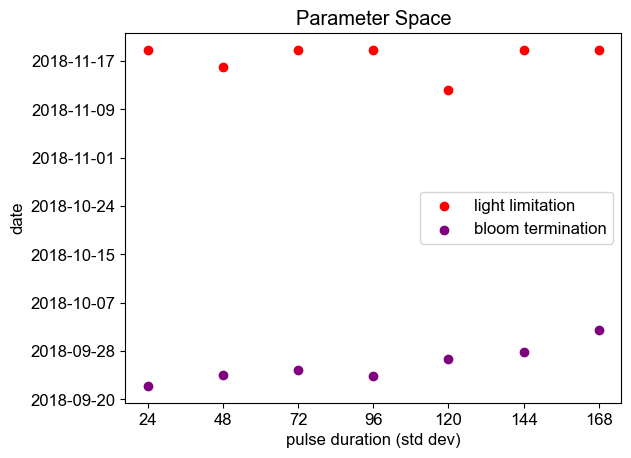

In [480]:
plt.scatter(std_dev, light_limited_series, color = 'red')
plt.scatter(std_dev, bloom_term, color = 'purple')
plt.yticks(ticks = [3400, 3600, 3800, 4000, 4200, 4400, 4600, 4800], labels = timestamp[[3400, 3600, 3800, 4000, 4200, 4400, 4600, 4800]].dt.date)
plt.xticks(ticks = std_dev)
plt.legend(['light limitation', 'bloom termination'], loc='center right')
plt.title('Parameter Space')
plt.xlabel('pulse duration (std dev)')
plt.ylabel('date')
plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/param_space.jpg', dpi=300, bbox_inches='tight')

In [ ]:
#parameter space: pulse quantity vs. bloom magnitude 

#software --> change F with every repetition, save onset of light limitation variable (nothing else) --> plot relationship

bloom_term= []
light_limited_series = []
bloom_magnitude = []
std_dev = [1, 2, 3, 4, 5]
for dev in std_dev: 
    #recalc light function: 3 tan decreases
    decayed_data_one, decay_function_one = create_tanh_decay(2205, light_data_2018.index, light_data_2018['approxPAR'])
    decayed_data_two, decay_function_two = create_tanh_decay(2541, decayed_data_one.index, decayed_data_one)
    decayed_data_three, decay_function_three = create_tanh_decay(2949, decayed_data_two.index, decayed_data_two)
    light_data_mod_pulses = pd.DataFrame({
        'time': light_data_2018.time,
        'approxPAR': decayed_data_three
    })
    #define npz system
    I_frac = [None] * len(time_eval)
    N_frac = [None] * len(time_eval)
    dP_stored = [None] * len(time_eval)
    def npz(t, X): #this model takes in temperature, nutrients (N), and irradiance (I)
        [N, P] = X
        Temp = T_interp(t)
        I_value = I_interp(t)
        PBI = P_B(I_value) #calculate dimensionaless irradiance: I_frac
        V_frac_calc = V_frac(N) #calculate dimensionaless nutrients: N_frac
        if V_frac_calc < 0: 
            V_frac_calc = 0 
        if I_frac[round(t)] == None: #takes the first value, not the last! 
            I_frac[round(t)] = (P_B(I_value)) #store I_frac
            N_frac[round(t)] = (V_frac_calc) #store N_frac
        [phyto_growth, phyto_resp, phyto_mortality] = phyto_rates(Temp, V_frac_calc, PBI) #calculate phyto rates based on Temperature
        #storm proximity forcing
        F = (1/np.sqrt(strat_index)) * (gaussian (t, 2205, 0.3, dev) + gaussian(t, 2541, 0.3, dev) +  gaussian(t, 2949, 0.3, dev))
        dN_dt = - (P*(phyto_growth-phyto_resp)) + N_in(t) + F
        #dN_dt = N + #create new function here!
        dP_dt = P*(phyto_growth-phyto_resp-(6*phyto_mortality)) #scale by 0.001 to reduce over-grazing
        if dP_stored[round(t)] == None:
            dP_stored[round(t)] = dP_dt #store dP_dt value 
        return [dN_dt, dP_dt]
    #initial condtions 
    N0 = 0.5
    P0 = 0.5
    init = [N0, P0]

    #time range
    time_eval = np.linspace(0, len(M2_2018_all)-1, len(M2_2018_all)) #create values to interpolate along
    time = (0, len(M2_2018_all)-1)
    #run model 
    M2_model = scipy.integrate.solve_ivp(npz, y0 = init, t_span = time, t_eval=time_eval, method='Radau', dense_output=False)

    #record bloom magnitude 
    bloom_magnitude.append(np.max(M2_model.y[1]))

    #calculate bloom termination
    dP_series = pd.Series(dP_stored)
    dP_smoothed = dP_series.rolling(475, min_periods=1).mean()

    if any(dP_smoothed < 0):
        first_negative = dP_smoothed[dP_smoothed < 0].iloc[0]
        first_negative_index = dP_smoothed[dP_smoothed < 0].index[0]
        print(f"First negative value {first_negative} occurs at {first_negative_index}")
    else:
        print("No negative values found")
    
    bloom_term.append(first_negative_index) #store bloom date
    
    #calculate light limitation
    I_frac = pd.Series(I_frac)
    N_frac = pd.Series(N_frac) #convert to series 

    I_frac_filled = I_frac.fillna(method='bfill').to_numpy()
    N_frac_filled = N_frac.fillna(method='bfill').to_numpy()

    nut_limited = np.where(I_frac_filled > N_frac_filled)
    light_limited = np.where(N_frac_filled > I_frac_filled)

    nut_limited = np.array(nut_limited).squeeze()
    light_limited = np.array(light_limited).squeeze()
    limitation_terms = np.ones_like(timestamp.index)

    limitation_terms[nut_limited] = 0 #1 is light limited, 0 is nutrient limited

    limitation_series = pd.Series(limitation_terms) #binary series

    # Now we can use rolling window: 
    w = 168
    consecutive_ones = limitation_series.rolling(window=w).sum()

    # Find where the sum equals 168
    full_day_light_limited = consecutive_ones == w

    # Find first occurrence
    if any(full_day_light_limited):
        first_occurrence = full_day_light_limited[full_day_light_limited].index[0]
        print(f"First week long period of light limitation starts at: {timestamp[first_occurrence]}")
    
    light_limited_series.append(first_occurrence) #store light date